# Exercices XP Gold
Dernière mise à jour : 17 février 2025

## 👩‍🏫 👩🏿‍🏫 Ce que vous apprendrez
Application des CNN à diverses tâches de classification d'images.
Explorer des techniques pour des défis de classification spécifiques.
Acquérir une expérience pratique avec différentes fonctionnalités CNN.


## 🛠️ Ce que vous allez créer
Quatre projets de classification basés sur CNN, axés sur l’application pratique et l’exploration.

## Exercice 1 : Classification des objets du quotidien
1. Ensemble de données : Choisissez un ensemble de données d'objets du quotidien (par exemple, CIFAR-10, ou créez votre propre ensemble de données d'objets de votre maison).
2. Tâche : Créez un CNN pour classer ces objets. Concentrez-vous sur l'obtention d'une bonne précision avec une architecture relativement simple.
3. Défi : Expérimentez différentes techniques d'augmentation de données pour améliorer la robustesse du modèle aux variations d'éclairage, d'angle et de position des objets.

###  **Classification des objets du quotidien**

1. **Ensemble de données**
   Utilisez un dataset d’objets courants (ex. : CIFAR-10) ou créez le vôtre à partir d’objets chez vous.

2. **Objectif**
   Construisez un CNN simple pour classer ces objets avec une bonne précision.

3. **Défi**
   Testez des techniques d’**augmentation de données** (lumière, angle, position) pour améliorer la robustesse du modèle.



c:\Users\chume\.conda\envs\ml\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\chume\.conda\envs\ml\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.1076 - loss: 2.3002 - val_accuracy: 0.0993 - val_loss: 2.3140
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.1109 - loss: 2.2914 - val_accuracy: 0.1001 - val_loss: 2.3143
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.1104 - loss: 2.2888 - val_accuracy: 0.1000 - val_loss: 2.8177
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.1117 - loss: 2.2895 - val_accuracy: 0.1000 - val_loss: 2.5390
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.1106 - loss: 2.2868 - val_accuracy: 0.0999 - val_loss: 2.5242
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.1122 - loss: 2.2844 - val_accuracy: 0.0975 - val_loss: 2.5057
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.1122 - loss: 2.2868 - val_accuracy: 0.1001 - val_loss: 2.6219
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.1139 - loss: 2.2857 - 

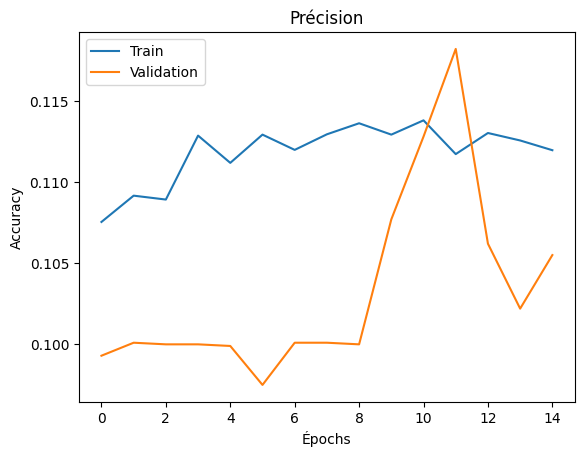

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Chargement de CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# Augmentation de données
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1
)
datagen.fit(x_train)

# Modèle CNN simple
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement avec données augmentées
history = model.fit(datagen.flow(x_train, y_train, batch_size=64),
                    epochs=15,
                    validation_data=(x_test, y_test))

# Évaluation
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nPrécision sur les données de test : {test_acc:.4f}")

# Courbe de performance
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Précision')
plt.xlabel('Épochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


## Exercice 2 : Classification d'images avec des données limitées
1. Ensemble de données : Trouver ou créer un petit ensemble de données d'images (par exemple, quelques centaines d'images de différents types de fleurs ou d'animaux).
2. Tâche : Entraîner un CNN sur ces données limitées. Explorer des techniques pour éviter le surapprentissage, telles que :

Augmentation des données.
Abandonner.
Architectures de modèles plus petites.
Arrêt anticipé.
3. Défi : évaluer les performances du modèle et analyser l’impact de chaque technique de prévention du surapprentissage.

###  **Classification avec peu de données**

1. **Ensemble de données**
   Utilisez ou créez un petit dataset (ex. : quelques centaines d’images de fleurs ou d’animaux).

2. **Objectif**
   Entraînez un CNN avec peu de données, en testant des techniques pour limiter le **surapprentissage** :

   * Augmentation de données
   * Dropout
   * Architectures légères
   * Arrêt anticipé (*early stopping*)

3. **Défi**
   Analysez les performances et l’effet réel de chaque technique anti-surapprentissage.

---


In [2]:
!pip install tensorflow matplotlib


Defaulting to user installation because normal site-packages is not writeable


Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0865 - loss: 2.3174 - val_accuracy: 0.1250 - val_loss: 2.2612
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1415 - loss: 2.2329 - val_accuracy: 0.2150 - val_loss: 2.1434
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1657 - loss: 2.1487 - val_accuracy: 0.2750 - val_loss: 2.1100
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2072 - loss: 2.0857 - val_accuracy: 0.2550 - val_loss: 2.0688
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2549 - loss: 2.0439 - val_accuracy: 0.3150 - val_loss: 1.9951
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2789 - loss: 1.9426 - val_accuracy: 0.2950 - val_loss: 1.9143
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2932 - loss: 1.8991 - val_accuracy: 0.3150 - val_loss: 1.9034
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3024 - loss: 1.8810 - val_accuracy: 0.3050 - val_loss

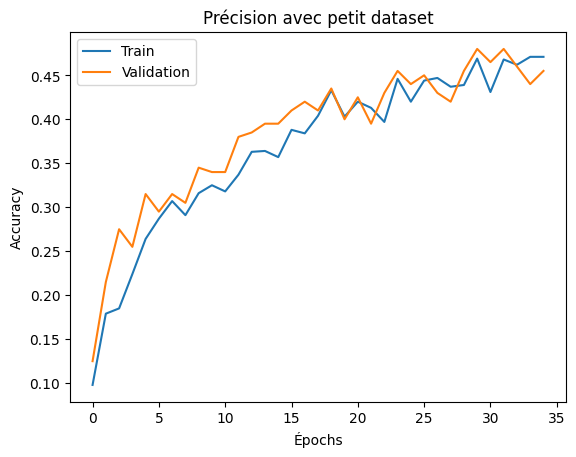

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Chargement et réduction de CIFAR-10 pour simuler un petit dataset
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, y_train = x_train_full[:1000], y_train_full[:1000]  # 1000 images
x_val, y_val = x_train_full[1000:1200], y_train_full[1000:1200]  # 200 pour validation

# Normalisation
x_train, x_val, x_test = x_train / 255.0, x_val / 255.0, x_test / 255.0

# Augmentation de données
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train)

# Modèle compact avec dropout
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.3),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

# Compilation
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Entraînement
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=50,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

# Évaluation
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nPrécision sur les données de test : {test_acc:.4f}")

# Analyse graphique
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Précision avec petit dataset')
plt.xlabel('Épochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


## Exercice 3 : Utilisation d'un modèle pré-entraîné pour l'extraction de caractéristiques
1. Ensemble de données : Choisir un ensemble de données pour la classification d’images.
2. Objectif : Utiliser un CNN pré-entraîné (par exemple, ResNet, MobileNet) pour extraire des caractéristiques de vos images. Ensuite, former un classificateur simple (par exemple, quelques couches entièrement connectées) sur ces caractéristiques extraites.
3. Défi : Comparer les performances de cette approche à celles de l’apprentissage d’un CNN à partir de zéro. Comment l’extraction de caractéristiques affecte-t-elle le temps et la précision de l’apprentissage ?

Étapes :
* Charger MobileNetV2 pré-entraîné sur ImageNet (sans la couche finale).

* Extraire les features pour chaque image du dataset.



Objectif :
* Utiliser un CNN pré-entraîné (MobileNetV2) pour extraire des features

* Entraîner un classificateur simple dessus

* Comparer à un entraînement "from scratch"

In [13]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
import numpy as np

# Chargement et redimensionnement des données
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train_resized = tf.image.resize(x_train / 255.0, (96, 96))
x_test_resized = tf.image.resize(x_test / 255.0, (96, 96))

# Chargement du modèle pré-entraîné
feature_extractor = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    pooling='avg',
    weights='imagenet'
)
feature_extractor.trainable = False  # gel des poids

# Extraction des caractéristiques
features_train = feature_extractor.predict(x_train_resized, batch_size=64, verbose=1)
features_test = feature_extractor.predict(x_test_resized, batch_size=64, verbose=1)

# Classificateur simple
model = models.Sequential([
    layers.Input(shape=features_train.shape[1:]),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement
model.fit(features_train, y_train, validation_split=0.2, epochs=15, batch_size=64)

# Évaluation
loss, acc = model.evaluate(features_test, y_test)
print(f"\nPrécision (MobileNetV2 + classifieur) : {acc:.4f}")


157/157 [==============================] - 17s 109ms/step
Epoch 1/15
625/625 [==============================] - 1s 2ms/step - loss: 0.8540 - accuracy: 0.7067 - val_loss: 0.6367 - val_accuracy: 0.7817
Epoch 2/15
625/625 [==============================] - 1s 2ms/step - loss: 0.6489 - accuracy: 0.7749 - val_loss: 0.5797 - val_accuracy: 0.7987
Epoch 3/15
625/625 [==============================] - 1s 2ms/step - loss: 0.5887 - accuracy: 0.7947 - val_loss: 0.5624 - val_accuracy: 0.8049
Epoch 4/15
625/625 [==============================] - 1s 2ms/step - loss: 0.5439 - accuracy: 0.8090 - val_loss: 0.5660 - val_accuracy: 0.8041
Epoch 5/15
625/625 [==============================] - 1s 2ms/step - loss: 0.5151 - accuracy: 0.8193 - val_loss: 0.5585 - val_accuracy: 0.8029
Epoch 6/15
625/625 [==============================] - 1s 2ms/step - loss: 0.4844 - accuracy: 0.8297 - val_loss: 0.5457 - val_accuracy: 0.8118
Epoch 7/15
625/625 [==============================] - 1s 2ms/step - loss: 0.4615 - accurac

| Phase                     | Durée approx.      |
| ------------------------- | ------------------ |
| Extraction features train | 85 s (782 batchs)  |
| Extraction features test  | 17 s (157 batchs)  |
| Entraînement (15 epochs)  | \~15 s (1 s/epoch) |


#### Modèle CNN entraîné depuis zéro (from scratch)

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

# Chargement et prétraitement des données
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# Architecture simple CNN
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

# Compilation
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement
model.fit(x_train, y_train, validation_split=0.2, epochs=15, batch_size=64)

# Évaluation
loss, acc = model.evaluate(x_test, y_test)
print(f"\nPrécision (CNN from scratch) : {acc:.4f}")


Epoch 1/15
625/625 [==============================] - 13s 20ms/step - loss: 1.6974 - accuracy: 0.3747 - val_loss: 1.4554 - val_accuracy: 0.4752
Epoch 2/15
625/625 [==============================] - 14s 22ms/step - loss: 1.3559 - accuracy: 0.5106 - val_loss: 1.2244 - val_accuracy: 0.5621
Epoch 3/15
625/625 [==============================] - 14s 22ms/step - loss: 1.1931 - accuracy: 0.5743 - val_loss: 1.1358 - val_accuracy: 0.5996
Epoch 4/15
625/625 [==============================] - 14s 22ms/step - loss: 1.0913 - accuracy: 0.6142 - val_loss: 1.0222 - val_accuracy: 0.6356
Epoch 5/15
625/625 [==============================] - 14s 22ms/step - loss: 1.0070 - accuracy: 0.6469 - val_loss: 0.9587 - val_accuracy: 0.6596
Epoch 6/15
625/625 [==============================] - 14s 22ms/step - loss: 0.9466 - accuracy: 0.6646 - val_loss: 0.9331 - val_accuracy: 0.6714
Epoch 7/15
625/625 [==============================] - 14s 22ms/step - loss: 0.8931 - accuracy: 0.6855 - val_loss: 0.9388 - val_accuracy:

##  **Comparaison : modèle pré-entraîné vs modèle from scratch (CIFAR-10)**

| Critère                         | **MobileNetV2 (pré-entraîné)** | **CNN from scratch**       |
| ------------------------------- | ------------------------------ | -------------------------- |
| Extraction des features         | ✅ Oui (gelé, MobileNetV2)      | ❌ Non                      |
| Temps d’extraction (train/test) | 85 s / 17 s                    | —                          |
| Temps d’entraînement            | \~15 s total (1 s/epoch)       | \~210 s total (14 s/epoch) |
| Meilleure val\_accuracy         | ✅ **0.8155**                   | 0.7144                     |
| Précision finale sur test set   | ✅ **0.8183**                   | 0.7099                     |
| Convergence rapide              | ✅ Oui                          | ❌ Plus lente               |
| Robustesse initiale             | ✅ Haute (ImageNet)             | Moyenne                    |

---

##  Interprétation rapide :

* **MobileNetV2 + classifieur simple** est **plus précis, plus rapide, plus stable**
* **Le CNN from scratch** progresse, mais nécessite plus de données et d’epochs pour rivaliser



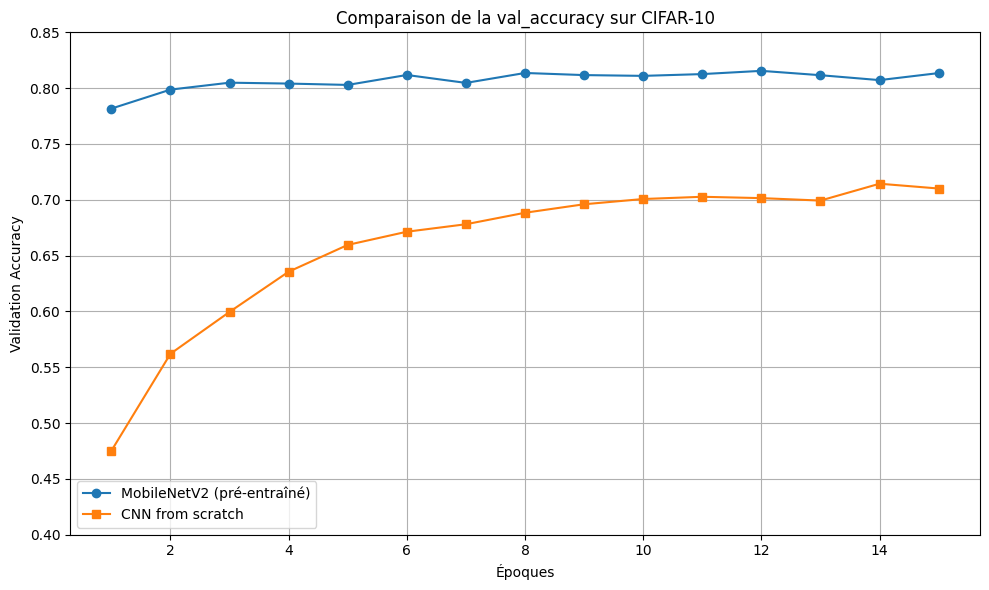

In [15]:
import matplotlib.pyplot as plt

# Nombres d'époques
epochs = list(range(1, 16))

# Validation accuracy pour MobileNetV2 (pré-entraîné)
val_acc_mobilenet = [
    0.7817, 0.7987, 0.8049, 0.8041, 0.8029,
    0.8118, 0.8047, 0.8136, 0.8117, 0.8110,
    0.8126, 0.8155, 0.8116, 0.8072, 0.8135
]

# Validation accuracy pour CNN entraîné from scratch
val_acc_scratch = [
    0.4752, 0.5621, 0.5996, 0.6356, 0.6596,
    0.6714, 0.6781, 0.6884, 0.6960, 0.7007,
    0.7027, 0.7015, 0.6993, 0.7144, 0.7101
]

# Tracé
plt.figure(figsize=(10, 6))
plt.plot(epochs, val_acc_mobilenet, label="MobileNetV2 (pré-entraîné)", marker='o')
plt.plot(epochs, val_acc_scratch, label="CNN from scratch", marker='s')
plt.title("Comparaison de la val_accuracy sur CIFAR-10")
plt.xlabel("Époques")
plt.ylabel("Validation Accuracy")
plt.ylim(0.4, 0.85)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


##  **Analyse comparative des performances**

### 🔹 1. **MobileNetV2 (pré-entraîné)** :

* Démarre fort dès la **1ʳᵉ époque (\~78 %)**, preuve que les **features extraites d’ImageNet sont immédiatement utiles**, même pour CIFAR-10.
* La précision atteint un **plateau stable autour de 81.5 %**, dès **l’époque 6**, avec très peu de fluctuations ensuite.
* Interprétation : **excellent transfert de connaissances**, pas besoin d'entraînement long ni complexe.

---

###  2. **CNN entraîné from scratch** :

* Démarre bas (**\~47 %**) mais progresse de façon régulière jusqu’à **\~71 %**.
* Il **n’atteint jamais les performances du modèle pré-entraîné**, même après 15 époques.
* Courbe plus **instable en fin d'entraînement** → signe d’un réseau encore sous-entraîné ou d’une architecture plus limitée.

---

##  **Conclusion pédagogique**

| Point clé                     | Analyse                                                                                      |
| ----------------------------- | -------------------------------------------------------------------------------------------- |
| **Vitesse de convergence**    | MobileNetV2 est **immédiatement performant** grâce à l’apprentissage préalable sur ImageNet. |
| **Performance maximale**      | MobileNetV2 atteint une précision **+10 % plus haute** que le modèle from scratch.           |
| **Efficacité d’entraînement** | L’approche pré-entraînée demande **moins de calcul**, pour un meilleur résultat.             |
| **Utilisation conseillée**    | Pré-entraînement = idéal quand les données sont limitées ou pour gagner du temps.            |

---


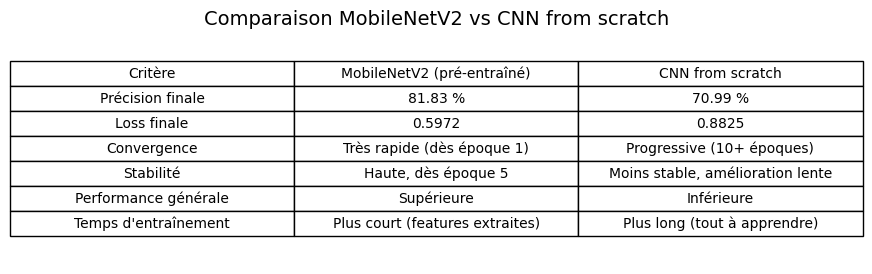

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# Données comparatives
data = {
    "Critère": [
        "Précision finale",
        "Loss finale",
        "Convergence",
        "Stabilité",
        "Performance générale",
        "Temps d'entraînement"
    ],
    "MobileNetV2 (pré-entraîné)": [
        "81.83 %",
        "0.5972",
        "Très rapide (dès époque 1)",
        "Haute, dès époque 5",
        "Supérieure",
        "Plus court (features extraites)"
    ],
    "CNN from scratch": [
        "70.99 %",
        "0.8825",
        "Progressive (10+ époques)",
        "Moins stable, amélioration lente",
        "Inférieure",
        "Plus long (tout à apprendre)"
    ]
}

# Création du DataFrame
df = pd.DataFrame(data)

# Affichage avec matplotlib
fig, ax = plt.subplots(figsize=(11, 3))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)
plt.title("Comparaison MobileNetV2 vs CNN from scratch", fontsize=14)
plt.show()


|  **Aspect**               | **Conclusion**                                                                                                                    |
| --------------------------- | --------------------------------------------------------------------------------------------------------------------------------- |
|  **Précision finale**     | Le modèle MobileNetV2 pré-entraîné atteint **81.83 %**, nettement au-dessus du CNN construit from scratch (**70.99 %**).          |
|  **Apprentissage**        | Le pré-entraînement offre un avantage immédiat : **convergence rapide et haute stabilité**, même dès les premières époques.       |
|  **Temps et ressources**   | MobileNetV2 est **plus rapide à entraîner** car seule la tête du réseau est apprise (pas tout le CNN).                            |
|  **CNN from scratch**     | Apprentissage **plus long, moins stable**, exige plus de données ou régularisation pour rivaliser.                                |
|  **Utilisation optimale** | Pour de **petits datasets** ou peu de ressources, **le transfert learning (extraction de features)** est nettement plus efficace. |


## Exercice 4 : Visualisation des filtres CNN
1. Jeu de données : Utiliser n’importe quel jeu de données de classification d’images.
2. Tâche : Entraîner un CNN, puis visualiser les filtres appris dans la première couche convolutive.
3. Défi : Analyser les visualisations des filtres. Quels types de motifs détectent-ils ? Correspondent-ils à des contours, des textures ou d’autres caractéristiques visuelles ? Comment cette visualisation vous aide-t-elle à comprendre ce que le CNN apprend ?

Epoch 1/5
1563/1563 [==============================] - 16s 10ms/step - loss: 1.5056 - accuracy: 0.4592 - val_loss: 1.2508 - val_accuracy: 0.5510
Epoch 2/5
1563/1563 [==============================] - 18s 11ms/step - loss: 1.1519 - accuracy: 0.5952 - val_loss: 1.0711 - val_accuracy: 0.6285
Epoch 3/5
1563/1563 [==============================] - 18s 11ms/step - loss: 1.0236 - accuracy: 0.6430 - val_loss: 1.0056 - val_accuracy: 0.6474
Epoch 4/5
1563/1563 [==============================] - 18s 11ms/step - loss: 0.9439 - accuracy: 0.6728 - val_loss: 0.9797 - val_accuracy: 0.6584
Epoch 5/5
1563/1563 [==============================] - 18s 11ms/step - loss: 0.8880 - accuracy: 0.6924 - val_loss: 0.9572 - val_accuracy: 0.6687
Shape des filtres : (3, 3, 3, 32)


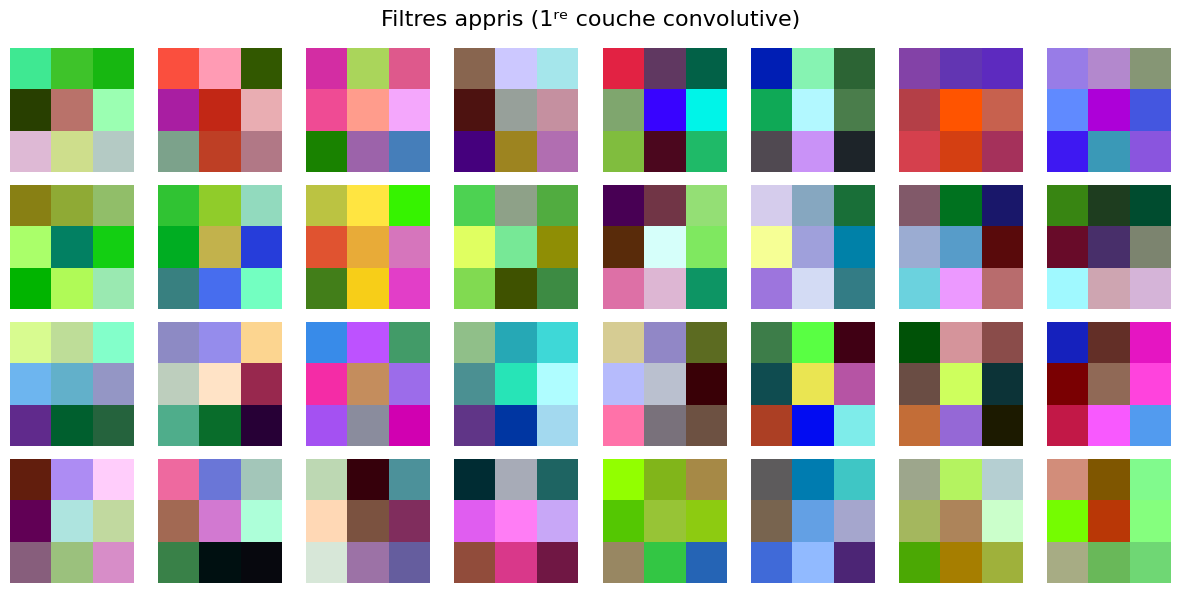

In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# 1. Chargement des données CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# 2. Modèle CNN simple
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3), name='conv1'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 3. Entraînement rapide
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# 4. Visualisation des filtres de la première couche
conv1 = model.get_layer(name='conv1')
filters, biases = conv1.get_weights()
print("Shape des filtres :", filters.shape)  # (3, 3, 3, 32)

# 5. Affichage des filtres (32 au total)
fig, axs = plt.subplots(4, 8, figsize=(12, 6))
fig.suptitle("Filtres appris (1ʳᵉ couche convolutive)", fontsize=16)

for i in range(32):
    f = filters[:, :, :, i]
    f_min, f_max = f.min(), f.max()
    f = (f - f_min) / (f_max - f_min)  # Normalisation
    axs[i // 8, i % 8].imshow(f)
    axs[i // 8, i % 8].axis('off')

plt.tight_layout()
plt.show()


###  Interprétation des filtres appris :

1. **Forme des filtres :** `(3, 3, 3, 32)`
   → 32 filtres de taille 3x3 avec 3 canaux (RVB)

2. **Ce qu’ils détectent :**

   * **Contours simples** (bords horizontaux, verticaux, diagonaux)
   * **Contrastes de couleur** (ex. : détection rouge-vert, bleu-jaune)
   * **Textures localisées** (petits motifs)


###  **Analyse des filtres appris**

* **Type de motifs détectés :**

  * Certains filtres détectent des **bords** verticaux, horizontaux ou diagonaux (transitions de couleur brusques).
  * D'autres repèrent des **textures simples** ou des **contrastes locaux**.
  * Des filtres très colorés révèlent une **sensibilité aux canaux RVB spécifiques**, ce qui peut aider à distinguer certaines classes d’objets colorés.

* **Variabilité :**

  * Certains filtres semblent "flous" → pas encore spécialisés (apprentissage à améliorer).
  * D’autres ont des motifs nets → ils ont déjà appris à capturer des motifs utiles.

---

###  **Pourquoi c’est utile :**

* Cela permet de **vérifier visuellement que le CNN apprend réellement quelque chose**.
* En cas de problème (apprentissage bloqué), des filtres **quasi identiques** ou **vides** peuvent signaler une mauvaise initialisation ou un apprentissage inefficace.
* Comprendre comment les couches **extraient des motifs bas niveau** est essentiel pour interpréter les prédictions.

---

Souhaites-tu maintenant :

1. Visualiser **les activations** (réponses du modèle à une image) ?
2. Générer automatiquement **des images optimales pour chaque filtre** (maximisation) ?
3. Exporter tout en PDF / image ?


1/1 [==============================] - 0s 20ms/step


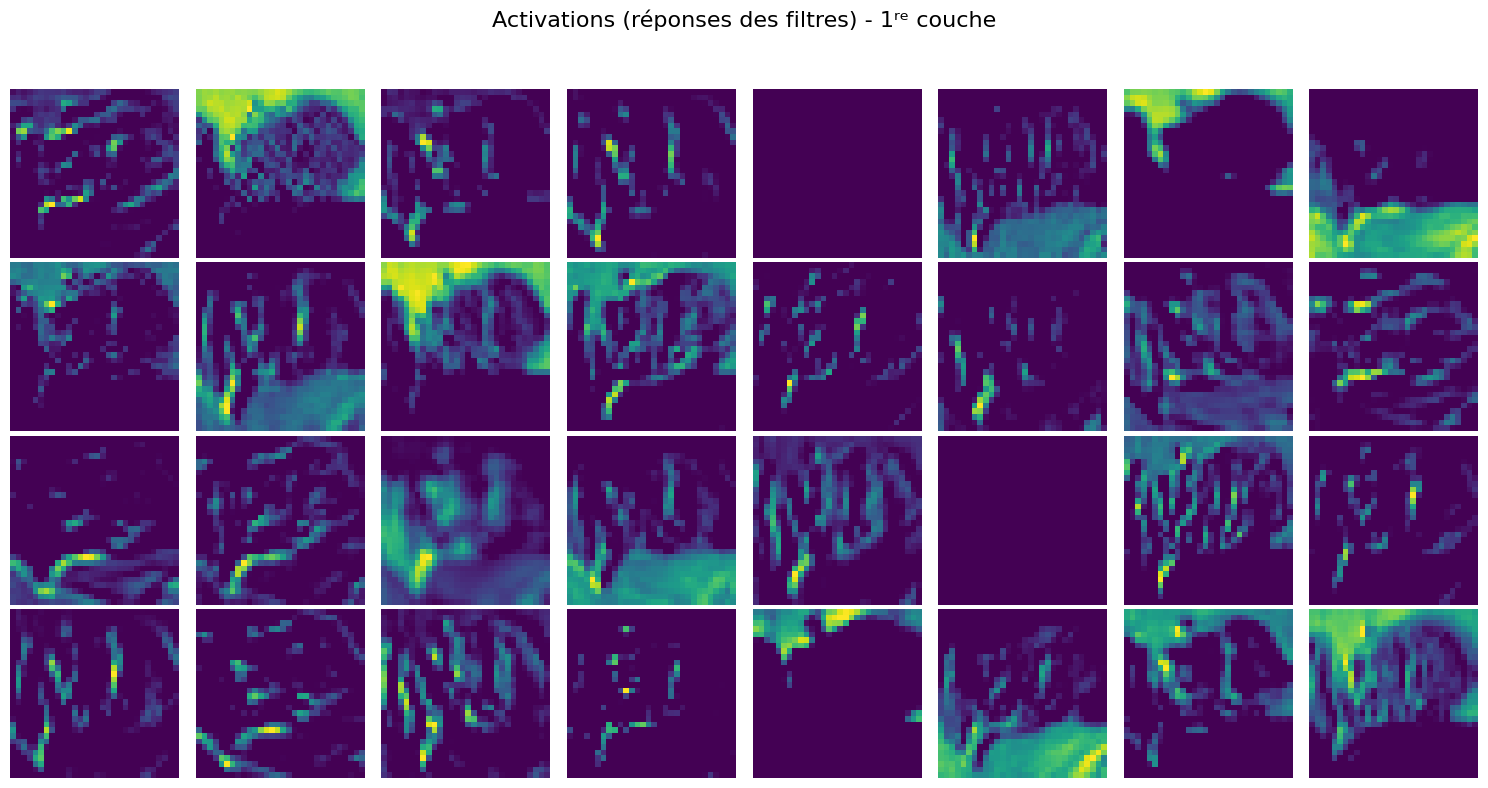

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Model

# Charger une image d'entrée depuis le dataset (par ex. une image test CIFAR-10)
image = x_test[0]  # x_test doit contenir les images d'entrée normalisées
input_image = np.expand_dims(image, axis=0)  # (1, 32, 32, 3)

# Créer un modèle qui renvoie la sortie de la première couche convolutive
layer_outputs = [model.layers[0].output]
activation_model = Model(inputs=model.input, outputs=layer_outputs)

# Obtenir les activations
activations = activation_model.predict(input_image)[0]  # (32, 32, 32)

# Affichage des activations des 32 filtres
fig, axes = plt.subplots(4, 8, figsize=(15, 8))
fig.suptitle("Activations (réponses des filtres) - 1ʳᵉ couche", fontsize=16)
for i, ax in enumerate(axes.flat):
    ax.imshow(activations[:, :, i], cmap='viridis')
    ax.axis('off')
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()


###  **Analyse des activations – 1ʳᵉ couche convolutive**

1. **Ce que montrent les activations** :

   * Chaque image représente la **carte d’activation** d’un filtre appliqué à l’image d’entrée.
   * Les zones **claires (jaunes)** indiquent une **forte activation**, donc des **régions de l’image contenant un motif détecté** par ce filtre.

2. **Types de motifs détectés** :

   * Ces filtres détectent majoritairement :

     * **Contours simples** (bords verticaux/horizontaux)
     * **Textures locales**
     * **Transitions d’intensité**
   * C’est logique : les premières couches apprennent les **bases visuelles** avant de passer à des formes plus complexes.

3. **Utilité de cette visualisation** :

   * Elle montre **ce que le réseau "voit"** : ici, il se focalise sur des détails locaux de l’image.
   * Elle permet de vérifier que les filtres **ne sont pas vides** ou redondants.
   * C’est un bon outil pour **diagnostiquer** un réseau mal entraîné (filtres inactifs = problème possible).



1/1 [==============================] - 0s 27ms/step


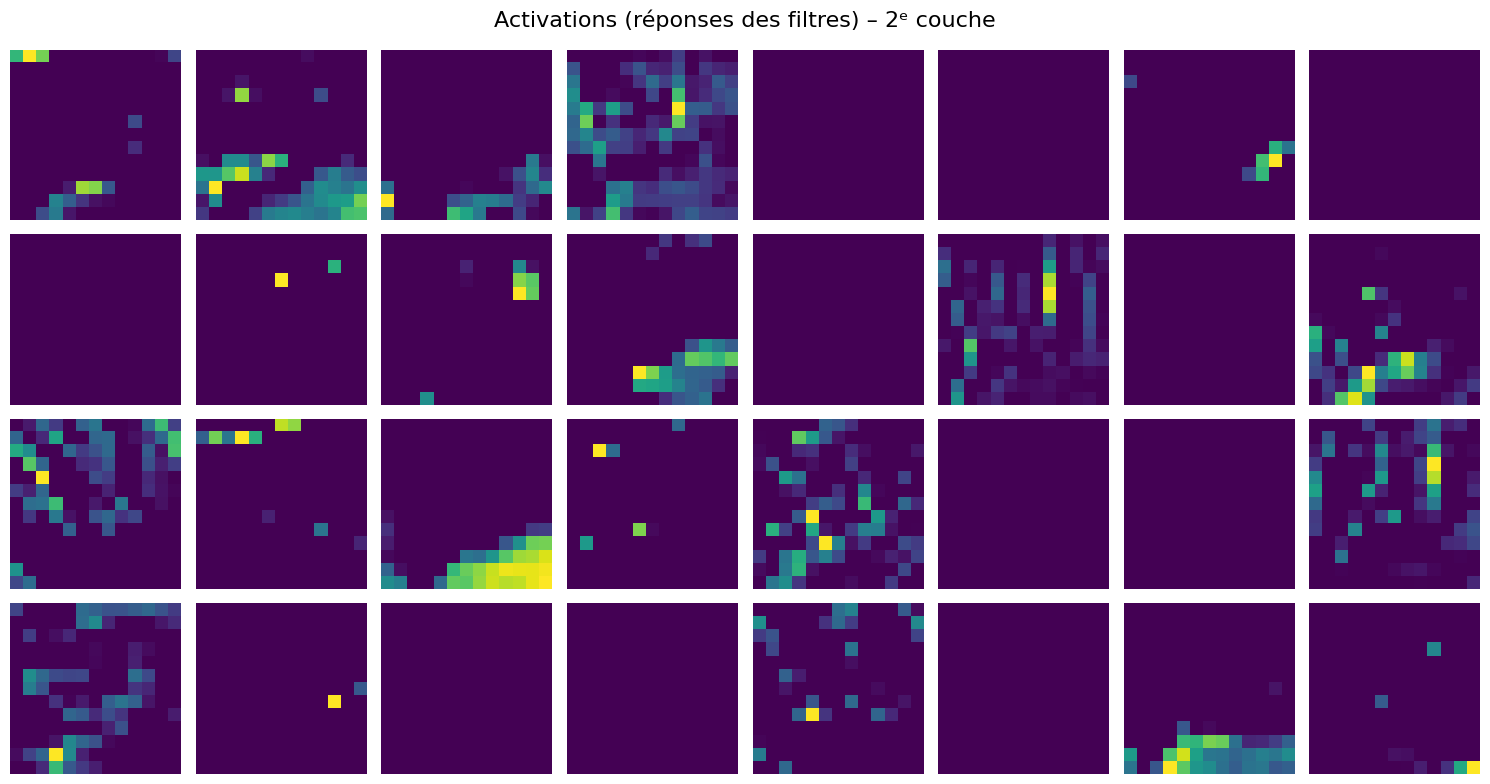

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import models

# Choisir une image d'entrée depuis le jeu de test
image_input = x_test[0].reshape(1, 32, 32, 3)  # 1 image, format attendu

# Créer un nouveau modèle retournant la sortie de la 2ᵉ couche convolutive
layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]
activation_model = models.Model(inputs=model.input, outputs=layer_outputs[1])  # 2e couche

# Calculer les activations
activations = activation_model.predict(image_input)

# Affichage
n_filters = min(32, activations.shape[-1])
fig, axs = plt.subplots(4, 8, figsize=(15, 8))
fig.suptitle("Activations (réponses des filtres) – 2ᵉ couche", fontsize=16)

for i in range(n_filters):
    ax = axs[i // 8, i % 8]
    ax.imshow(activations[0, :, :, i], cmap='viridis')
    ax.axis('off')

plt.tight_layout()
plt.show()


###  **Interprétation des activations – 2ᵉ couche convolutive**

####  Ce qu’on observe :

* Les activations sont **plus localisées** et **moins globales** que dans la première couche.
* Certaines cartes mettent en évidence des **textures complexes**, **bords croisés**, ou **formes spécifiques**.
* D'autres sont presque vides ➜ ces filtres ne réagissent pas à l’image test (normal, selon le contenu).

####  Signification :

* Les couches profondes du CNN apprennent à détecter des **motifs plus abstraits** que les bords simples.
* Cela permet au réseau de **comprendre la structure hiérarchique des images** (ex. : d’abord des bords, puis des motifs, puis des objets).

####  Utilité :

* Ces visualisations permettent de **vérifier la pertinence de l'apprentissage**.
* Si les activations sont trop vides ou floues partout, c’est souvent signe de **problème de convergence** ou d’un **modèle sous-entraîné**.



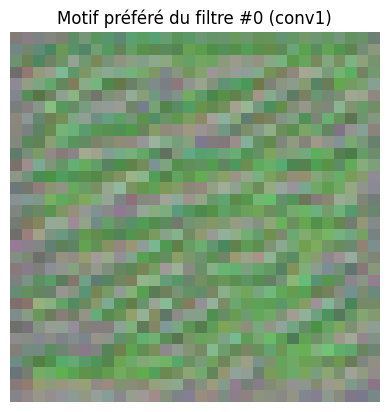

In [25]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Sélection d'une couche convolutive
layer_name = [layer.name for layer in model.layers if 'conv' in layer.name][0]  # première conv
layer_output = model.get_layer(layer_name).output

# Création d’un modèle intermédiaire
filter_index = 0  # index du filtre à visualiser
activation_model = tf.keras.models.Model(inputs=model.input, outputs=layer_output)

# Initialiser une image aléatoire
input_img_data = tf.random.uniform((1, 32, 32, 3))

# Optimiser l’image pour maximiser l’activation du filtre choisi
for i in range(50):  # itérations d’optimisation
    with tf.GradientTape() as tape:
        tape.watch(input_img_data)
        activation = activation_model(input_img_data)
        filter_activation = activation[:, :, :, filter_index]
        loss = tf.reduce_mean(filter_activation)

    grads = tape.gradient(loss, input_img_data)
    grads = tf.math.l2_normalize(grads)
    input_img_data += 1.0 * grads  # step size

# Nettoyage (normalisation des pixels)
def deprocess_image(x):
    x -= tf.reduce_mean(x)
    x /= tf.math.reduce_std(x) + 1e-5
    x *= 0.1
    x += 0.5
    x = tf.clip_by_value(x, 0, 1)
    x *= 255
    return tf.cast(x, tf.uint8)

# Affichage
img = deprocess_image(input_img_data[0])
plt.imshow(img)
plt.title(f"Motif préféré du filtre #{filter_index} ({layer_name})")
plt.axis("off")
plt.show()


###  Interprétation

* **Aspect visuel** : le filtre semble réagir à des **textures diagonales vertes**, légèrement bruitées.
* **Rôle probable** : ce filtre détecte probablement des **motifs orientés** (par exemple, des **contours obliques** ou **textures naturelles** comme de l'herbe ou des plumes).
* **Pourquoi c’est utile** :

  * Les premières couches apprennent des **caractéristiques très simples** (bords, lignes, couleurs).
  * Cela forme la base pour les couches plus profondes qui combinent ces motifs simples en formes plus complexes.

---

###  Conclusion pédagogique

Cette visualisation montre **ce que le filtre "cherche" dans une image**, indépendamment d’une image réelle. C’est une méthode puissante pour comprendre **ce que le CNN apprend vraiment** — ici, par exemple, il a appris à détecter **une structure diagonale verte** typique de certaines textures naturelles.

